**4.Feature Extraction**

**Use VGG16 to extract features, then train a small classifier on top.**

**Steps:Image → VGG16 (frozen) → feature vector → classifier**

2026-03-26 18:45:36.096618: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774550736.255081      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774550736.303073      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774550736.662372      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774550736.662403      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774550736.662405      55 computation_placer.cc:177] computation placer alr

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.
Classes: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1774550772.048422     127 service.cc:152] XLA service 0x786da0005ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774550772.048468     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774550772.048473     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774550772.626111     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/176 ━━━━━━━━━━━━━━━━━━━━ 29:31 10s/step - accuracy: 0.1406 - loss: 2.0691

I0000 00:00:1774550780.140382     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


176/176 ━━━━━━━━━━━━━━━━━━━━ 107s 553ms/step - accuracy: 0.2759 - loss: 1.7157 - val_accuracy: 0.7037 - val_loss: 1.1223
Epoch 2/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 57s 325ms/step - accuracy: 0.5908 - loss: 1.1247 - val_accuracy: 0.7483 - val_loss: 0.8605
Epoch 3/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 318ms/step - accuracy: 0.6631 - loss: 0.9205 - val_accuracy: 0.7579 - val_loss: 0.7465
Epoch 4/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 56s 316ms/step - accuracy: 0.7025 - loss: 0.8205 - val_accuracy: 0.7800 - val_loss: 0.6782
Epoch 5/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 313ms/step - accuracy: 0.7278 - loss: 0.7574 - val_accuracy: 0.7889 - val_loss: 0.6321
Epoch 6/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 310ms/step - accuracy: 0.7490 - loss: 0.7063 - val_accuracy: 0.7993 - val_loss: 0.5962
Epoch 7/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 312ms/step - accuracy: 0.7571 - loss: 0.6773 - val_accuracy: 0.8053 - val_loss: 0.5738
Epoch 8/30
176/176 ━━━━━━━━━━━━━━━━━━━━ 55s 311ms/step - accuracy: 0.7519 - loss: 0.6636 - va

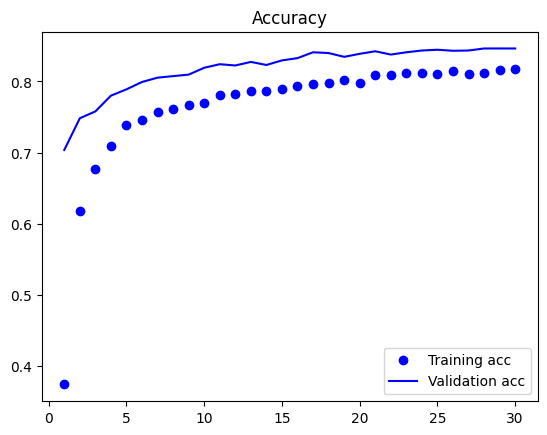

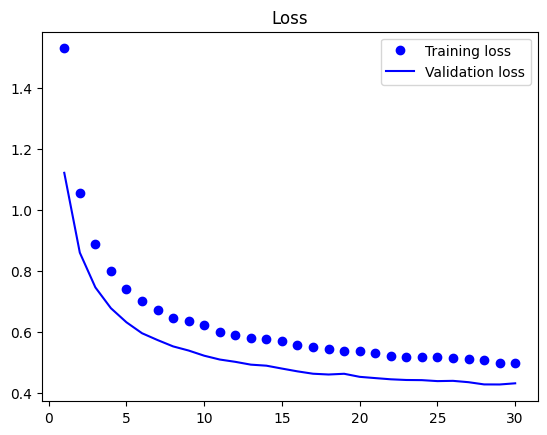

In [1]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, GlobalAveragePooling2D
from tensorflow.keras import mixed_precision
import matplotlib.pyplot as plt

# 🔥 GPU optimization
mixed_precision.set_global_policy('mixed_float16')

# Load VGG16
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

conv_base.trainable = False

train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"


# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

BATCH_SIZE = 64

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # ✅ changed
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(128,128),
    batch_size=BATCH_SIZE,
    class_mode='categorical'   # ✅ changed
)

# 🔍 Check classes
print("Classes:", train_generator.class_indices)
num_classes = train_generator.num_classes

# Model
model = models.Sequential([
    Input(shape=(128,128,3)),
    conv_base,
    GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')   # ✅ changed
])

# Compile
model.compile(
    loss='categorical_crossentropy',   # ✅ changed
    optimizer=optimizers.Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator
)

# 💾 Save model
#model.save("/content/drive/MyDrive/Colab Notebooks/DL/assignment/vgg16_categorical.keras")

# Plot
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.legend()
plt.title('Accuracy')

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.legend()
plt.title('Loss')

plt.show()